# Instagram Engagement Analysis

### Alfido Tech Internship

**Name:** Saniya Shiya  
**Project:** Instagram Engagement Analysis  
**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Google Colab

---

## Project Overview

Social media platforms generate large amounts of user interaction data that can be analyzed to understand audience behavior and improve content strategy.

The objective of this project is to analyze Instagram engagement data to identify patterns in content performance, hashtag usage, follower relationships, and user engagement. The analysis aims to provide insights that can help optimize social media strategies for improved engagement.

## Objectives

The main objectives of this project are:

- Analyze Instagram engagement data.
- Identify the most common content types.
- Study the relationship between content type and engagement.
- Analyze hashtag usage and its impact on comments.
- Explore follower distribution among users.
- Recommend strategies to improve Instagram engagement.

## Dataset Information

**Source:** Kaggle – Instagram Dataset

The dataset consists of seven CSV files:

- likes.csv
- follows.csv
- tags.csv
- comments.csv
- photo_tags.csv
- users.csv
- photos.csv

These datasets contain information related to users, posts, likes, comments, hashtags, and follower relationships.

## Dataset



In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhanupratapbiswas/instgram")

print("Path to dataset files:", path)

100%|██████████| 151k/151k [00:00<00:00, 363kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/bhanupratapbiswas/instgram/versions/1


In [ ]:
import os

print(os.listdir(path))

['likes.csv', 'follows.csv', 'tags.csv', 'comments.csv', 'photo_tags.csv', 'users.csv', 'photos.csv']


In [ ]:
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/root/.cache/kagglehub/datasets/bhanupratapbiswas/instgram/versions/1/likes.csv
/root/.cache/kagglehub/datasets/bhanupratapbiswas/instgram/versions/1/follows.csv
/root/.cache/kagglehub/datasets/bhanupratapbiswas/instgram/versions/1/tags.csv
/root/.cache/kagglehub/datasets/bhanupratapbiswas/instgram/versions/1/comments.csv
/root/.cache/kagglehub/datasets/bhanupratapbiswas/instgram/versions/1/photo_tags.csv
/root/.cache/kagglehub/datasets/bhanupratapbiswas/instgram/versions/1/users.csv
/root/.cache/kagglehub/datasets/bhanupratapbiswas/instgram/versions/1/photos.csv


In [ ]:
import pandas as pd

likes = pd.read_csv(path + "/likes.csv")
follows = pd.read_csv(path + "/follows.csv")
tags = pd.read_csv(path + "/tags.csv")
comments = pd.read_csv(path + "/comments.csv")
photo_tags = pd.read_csv(path + "/photo_tags.csv")
users = pd.read_csv(path + "/users.csv")
photos = pd.read_csv(path + "/photos.csv")

In [ ]:
print("Likes:")
display(likes.head())

print("Follows:")
display(follows.head())

print("Tags:")
display(tags.head())

print("Comments:")
display(comments.head())

print("Photo Tags:")
display(photo_tags.head())

print("Users:")
display(users.head())

print("Photos:")
display(photos.head())

Likes:


,user,photo,created time,following or not,like type
0,2,1,13-04-2023 08:04,yes,heart emoji
1,2,4,13-04-2023 08:04,no,thumbs up
2,2,8,13-04-2023 08:04,yes,laughing
3,2,9,13-04-2023 08:04,no,fire
4,2,10,13-04-2023 08:04,yes,clap


Follows:


,follower,followee,created time,is follower active,followee Acc status
0,2,1,13-04-2023 08:04,1,Private
1,2,3,13-04-2023 08:04,0,private
2,2,4,13-04-2023 08:04,0,public
3,2,5,13-04-2023 08:04,0,private
4,2,6,13-04-2023 08:04,1,private


Tags:


...

,photo,tag ID,user id
0,1,13,1
1,1,17,1
2,1,18,2
3,1,19,2
4,1,21,3


Users:


,id,name,created time,private/public,post count,Verified status
0,1,Kenton_Kirlin,16-02-2017 18:22,yes,11,no
1,2,Andre_Purdy85,02-04-2017 17:11,no,7,no
2,3,Harley_Lind18,21-02-2017 11:12,no,2,no
3,4,Arely_Bogan63,13-08-2016 01:28,yes,1,no
4,5,Aniya_Hackett,07-12-2016 01:04,yes,3,no


Photos:


,id,image link,user ID,created dat,Insta filter used,photo type
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo


## Exploratory Data Analysis

In [ ]:
datasets = {
    "Likes": likes,
    "Follows": follows,
    "Tags": tags,
    "Comments": comments,
    "Photo Tags": photo_tags,
    "Users": users,
    "Photos": photos
}

for name, df in datasets.items():
    print("=" * 50)
    print(name)
    print("=" * 50)

    print("\nShape:")
    print(df.shape)

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nSummary Statistics:")
    display(df.describe(include="all"))

Likes

Shape:
(8782, 5)

Data Types:
user                 int64
photo                int64
created time        object
following or not    object
like type           object
dtype: object

Missing Values:
user                0
photo               0
created time        0
following or not    0
like type           0
dtype: int64

Summary Statistics:


,user,photo,created time,following or not,like type
count,8782.000000,8782.000000,8782,8782,8782
unique,NaN,NaN,1,2,7
top,NaN,NaN,13-04-2023 08:04,yes,clap
freq,NaN,NaN,8782,5853,1754
mean,48.320314,128.550444,NaN,NaN,NaN
std,28.470237,73.782136,NaN,NaN,NaN
min,2.000000,1.000000,NaN,NaN,NaN
25%,22.000000,64.250000,NaN,NaN,NaN
50%,47.000000,128.000000,NaN,NaN,NaN
75%,71.000000,192.000000,NaN,NaN,NaN


Follows

Shape:
(7623, 5)

Data Types:
follower                int64
followee                int64
created time           object
is follower active      int64
followee Acc status    object
dtype: object

Missing Values:
follower               0
followee               0
created time           0
is follower active     0
followee Acc status    0
dtype: int64

Summary Statistics:


,follower,followee,created time,is follower active,followee Acc status
count,7623.000000,7623.000000,7623,7623.000000,7623
unique,NaN,NaN,1,NaN,3
top,NaN,NaN,13-04-2023 08:04,NaN,public
freq,NaN,NaN,7623,NaN,3054
mean,48.519481,50.520005,NaN,0.550571,NaN
std,29.292942,28.862946,NaN,0.497469,NaN
min,2.000000,1.000000,NaN,0.000000,NaN
25%,22.000000,26.000000,NaN,0.000000,NaN
50%,46.000000,51.000000,NaN,1.000000,NaN
75%,72.000000,76.000000,NaN,1.000000,NaN


Tags

Shape:
(21, 4)

Data Types:
id               int64
tag text        object
created time    object
location        object
dtype: object

Missing Values:
id              0
tag text        0
created time    0
location        0
dtype: int64

Summary Statistics:


...

,photo,tag ID,user id
count,501.000000,501.000000,501.000000
mean,125.750499,12.792415,2.377246
std,76.128100,6.231920,2.005842
min,1.000000,1.000000,1.000000
25%,60.000000,8.000000,1.000000
50%,126.000000,13.000000,1.000000
75%,194.000000,18.000000,3.000000
max,257.000000,21.000000,6.000000


Users

Shape:
(100, 6)

Data Types:
id                  int64
name               object
created time       object
private/public     object
post count          int64
Verified status    object
dtype: object

Missing Values:
id                 0
name               0
created time       0
private/public     0
post count         0
Verified status    0
dtype: int64

Summary Statistics:


,id,name,created time,private/public,post count,Verified status
count,100.000000,100,100,100,100.000000,100
unique,NaN,100,100,2,NaN,2
top,NaN,Kenton_Kirlin,16-02-2017 18:22,yes,NaN,no
freq,NaN,1,1,50,NaN,92
mean,50.500000,NaN,NaN,NaN,215.370000,NaN
std,29.011492,NaN,NaN,NaN,534.756995,NaN
min,1.000000,NaN,NaN,NaN,0.000000,NaN
25%,25.750000,NaN,NaN,NaN,2.000000,NaN
50%,50.500000,NaN,NaN,NaN,12.000000,NaN
75%,75.250000,NaN,NaN,NaN,78.000000,NaN


Photos

Shape:
(257, 6)

Data Types:
id                    int64
image link           object
user ID               int64
created dat          object
Insta filter used    object
photo type           object
dtype: object

Missing Values:
id                   0
image link           0
user ID              0
created dat          0
Insta filter used    0
photo type           0
dtype: int64

Summary Statistics:


,id,image link,user ID,created dat,Insta filter used,photo type
count,257.000000,257,257.000000,257,257,257
unique,NaN,257,NaN,1,2,3
top,NaN,http://dedrick.info,NaN,13-04-2023 08:04,yes,photo
freq,NaN,1,NaN,257,142,155
mean,129.000000,NaN,47.330739,NaN,NaN,NaN
std,74.333707,NaN,29.475817,NaN,NaN,NaN
min,1.000000,NaN,1.000000,NaN,NaN,NaN
25%,65.000000,NaN,23.000000,NaN,NaN,NaN
50%,129.000000,NaN,47.000000,NaN,NaN,NaN
75%,193.000000,NaN,72.000000,NaN,NaN,NaN


In [ ]:
datasets = {
    "Likes": likes,
    "Follows": follows,
    "Tags": tags,
    "Comments": comments,
    "Photo Tags": photo_tags,
    "Users": users,
    "Photos": photos
}

for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

Likes: 0 duplicate rows
Follows: 0 duplicate rows
Tags: 0 duplicate rows
Comments: 0 duplicate rows
Photo Tags: 0 duplicate rows
Users: 0 duplicate rows
Photos: 0 duplicate rows


## Data Visualization

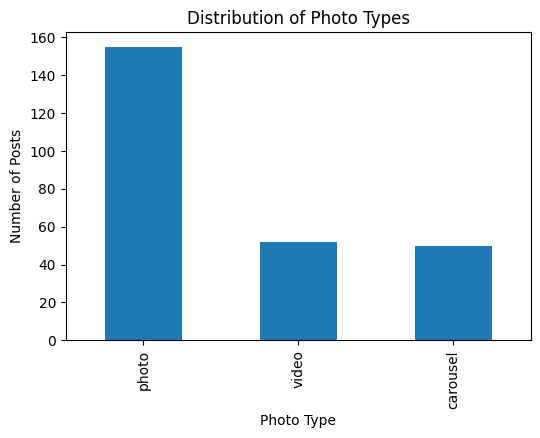

In [ ]:
import matplotlib.pyplot as plt

photo_type_counts = photos["photo type"].value_counts()

plt.figure(figsize=(6,4))
photo_type_counts.plot(kind="bar")

plt.title("Distribution of Photo Types")
plt.xlabel("Photo Type")
plt.ylabel("Number of Posts")

plt.show()

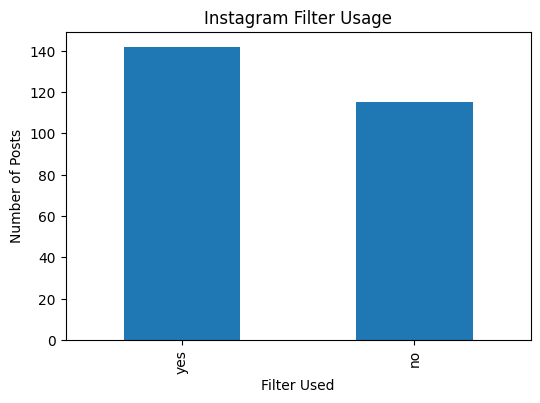

In [ ]:
filter_counts = photos["Insta filter used"].value_counts()

plt.figure(figsize=(6,4))
filter_counts.plot(kind="bar")

plt.title("Instagram Filter Usage")
plt.xlabel("Filter Used")
plt.ylabel("Number of Posts")

plt.show()

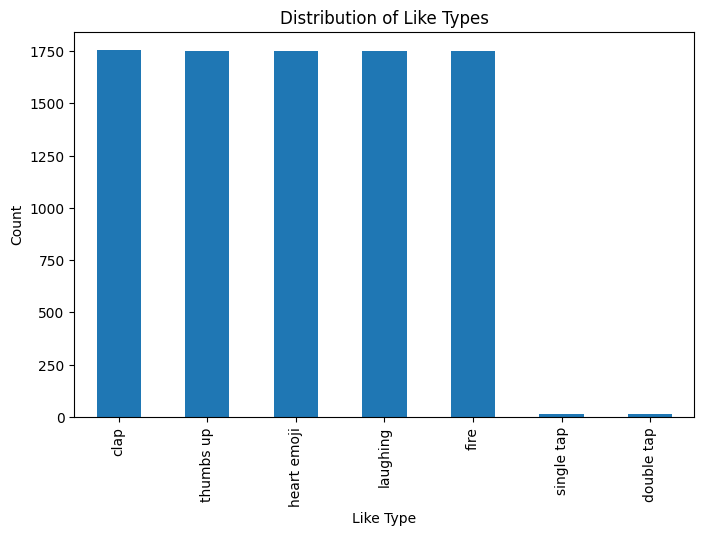

In [ ]:
plt.figure(figsize=(8,5))

likes["like type"].value_counts().plot(kind="bar")

plt.title("Distribution of Like Types")
plt.xlabel("Like Type")
plt.ylabel("Count")

plt.show()

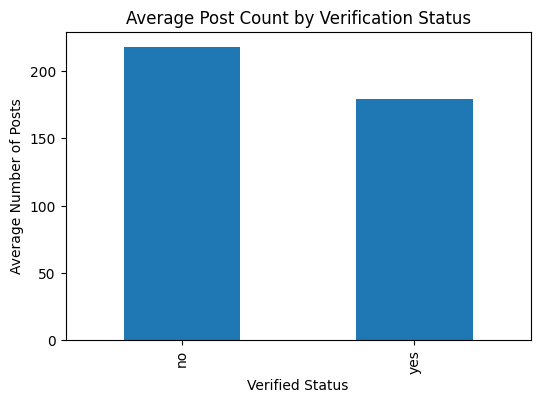

In [ ]:
import matplotlib.pyplot as plt

avg_posts = users.groupby("Verified status")["post count"].mean()

plt.figure(figsize=(6,4))
avg_posts.plot(kind="bar")

plt.title("Average Post Count by Verification Status")
plt.xlabel("Verified Status")
plt.ylabel("Average Number of Posts")

plt.show()

In [ ]:
likes["created time"] = pd.to_datetime(
    likes["created time"],
    format="%d-%m-%Y %H:%M"
)

photos["created dat"] = pd.to_datetime(
    photos["created dat"],
    format="%d-%m-%Y %H:%M"
)

comments["created Timestamp"] = pd.to_datetime(
    comments["created Timestamp"],
    format="%d-%m-%Y %H:%M"
)

In [ ]:
photos["Hour"] = photos["created dat"].dt.hour

photos[["created dat", "Hour"]].head()

,created dat,Hour
0,2023-04-13 08:04:00,8
1,2023-04-13 08:04:00,8
2,2023-04-13 08:04:00,8
3,2023-04-13 08:04:00,8
4,2023-04-13 08:04:00,8


## Engagement Analysis

In [ ]:

likes_per_photo = likes.groupby("photo").size().reset_index(name="Total Likes")


photo_engagement = photos.merge(
    likes_per_photo,
    left_on="id",
    right_on="photo",
    how="left"
)

photo_engagement["Total Likes"] = photo_engagement["Total Likes"].fillna(0)

photo_engagement.head()

,id,image link,user ID,created dat,Insta filter used,photo type,Hour,photo,Total Likes
0,1,http://elijah.biz,1,2023-04-13 08:04:00,yes,photo,8,1,25
1,2,https://shanon.org,1,2023-04-13 08:04:00,no,photo,8,2,36
2,3,http://vicky.biz,1,2023-04-13 08:04:00,no,photo,8,3,38
3,4,http://oleta.net,1,2023-04-13 08:04:00,no,photo,8,4,38
4,5,https://jennings.biz,1,2023-04-13 08:04:00,yes,photo,8,5,31


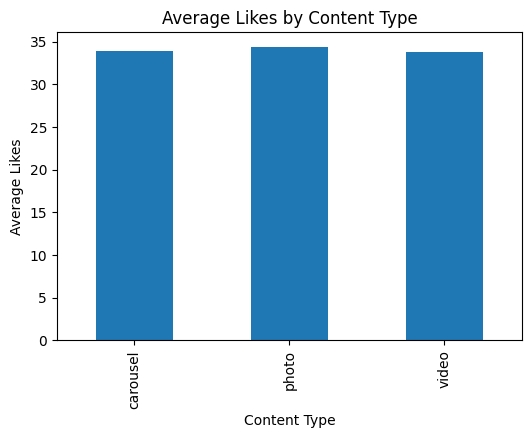

In [ ]:
avg_likes = photo_engagement.groupby("photo type")["Total Likes"].mean()

plt.figure(figsize=(6,4))
avg_likes.plot(kind="bar")

plt.title("Average Likes by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Average Likes")

plt.show()

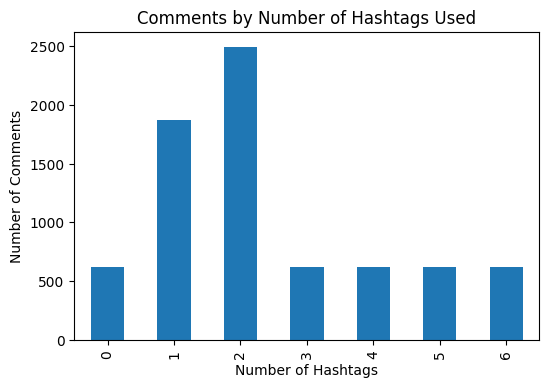

In [ ]:
hashtag_analysis = comments.groupby("Hashtags used count").size()

plt.figure(figsize=(6,4))
hashtag_analysis.plot(kind="bar")

plt.title("Comments by Number of Hashtags Used")
plt.xlabel("Number of Hashtags")
plt.ylabel("Number of Comments")

plt.show()

In [ ]:
top_photos = photo_engagement.sort_values(
    by="Total Likes",
    ascending=False
)[["id", "photo type", "Insta filter used", "Total Likes"]]

top_photos.head(10)

,id,photo type,Insta filter used,Total Likes
144,145,video,yes,48
126,127,photo,yes,43
181,182,photo,no,43
122,123,photo,yes,42
29,30,carousel,no,41
51,52,photo,yes,41
60,61,photo,yes,41
173,174,carousel,no,41
255,256,photo,no,41
191,192,photo,no,41


## Dataset Summary and Follower Analysis

In [ ]:
summary = pd.DataFrame({
    "Metric": [
        "Total Users",
        "Total Photos",
        "Total Likes",
        "Total Comments",
        "Total Tags"
    ],
    "Value": [
        len(users),
        len(photos),
        len(likes),
        len(comments),
        len(tags)
    ]
})

summary

,Metric,Value
0,Total Users,100
1,Total Photos,257
2,Total Likes,8782
3,Total Comments,7488
4,Total Tags,21


In [ ]:
print(follows.columns.tolist())

['follower', 'followee ', 'created time', 'is follower active', 'followee Acc status']


In [ ]:
followers = follows.groupby("followee ").size().reset_index(name="Followers")

top_followed = followers.sort_values(
    by="Followers",
    ascending=False
)

top_followed.head(10)

,followee,Followers
0,1,77
24,25,77
33,34,77
6,7,77
28,29,77
22,23,77
79,80,77
76,77,77
80,81,77
89,90,77


## Overall Findings

The analysis of the Instagram engagement dataset revealed several useful insights:

- Photos are the most frequently posted content type.
- Most posts use Instagram filters.
- Photo posts receive slightly higher average likes than videos and carousel posts.
- Posts containing two hashtags received the highest number of comments.
- The follower distribution is fairly balanced across users.
- Engagement differences between content types are relatively small.

## Limitations

The dataset contains some limitations that affect the analysis:

- All posts have the same timestamp (8:04 AM), making it impossible to determine the best posting time.
- The dataset appears to be synthetic rather than collected from a real Instagram account.
- Differences in engagement between content types are relatively small.
- Results should be interpreted only within the context of this dataset.

## Recommendations

Based on the analysis, the following strategies are recommended:

- Continue prioritizing photo posts since they receive slightly higher engagement.
- Use approximately two relevant hashtags per post.
- Apply Instagram filters when appropriate to improve visual appeal.
- Maintain a consistent posting schedule.
- Monitor audience engagement regularly and adjust the content strategy using real-world analytics.

# Conclusion

This project analyzed Instagram engagement data to understand posting patterns, content performance, hashtag usage, and follower trends.

Although the dataset had limitations, particularly the identical posting timestamps, the analysis provided meaningful insights into user engagement. Photo posts performed slightly better than other content types, moderate hashtag usage generated more comments, and follower distribution remained balanced across users.

These findings can help organizations like Alfido Tech make more informed social media decisions while highlighting the importance of using real-world datasets for deeper engagement analysis.